# Cellpose on Registered Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from cellpose import models, core
from mbo_utilities import imread
import lbm_suite2p_python as lsp

print(f"GPU available: {core.use_gpu()}")

GPU available: True


## Run registration only defaults

In [3]:
rarray = imread("D:/cj/2025-11-21/raw/vdaq1")
rarray.metadata

Counting frames:   0%|          | 0/1 [00:00<?, ?it/s]

{'num_planes': 2,
 'num_rois': 5,
 'fov': [490, 2550],
 'fov_px': [148, 770],
 'frame_rate': 5.396220259154953,
 'pixel_resolution': (3.31, 3.31),
 'ndim': 2,
 'dtype': 'int16',
 'size': 637686,
 'page_height': 4338,
 'page_width': 147,
 'objective_resolution': 156.44,
 'zoom_factor': 2,
 'uniform_sampling': 1,
 'num_fly_to_lines': 120,
 'roi_heights': [770, 770, 770, 770, 770],
 'roi_groups': [{'ver': 1,
   'classname': 'scanimage.mroi.Roi',
   'name': 'ROI 1',
   'roiUuid': 'F42D1725852B3154',
   'roiUuiduint64': 1.759474477e+19,
   'zs': 0,
   'scanfields': {'ver': 1,
    'classname': 'scanimage.mroi.scanfield.fields.RotatedRectangle',
    'roiUuid': '4555369DC8EC3B01',
    'roiUuiduint64': 4.995959413e+18,
    'centerXY': [-6.264382511, 0],
    'sizeXY': [3.132191255, 16.30017898],
    'rotationDegrees': 0,
    'enable': 1,
    'pixelResolutionXY': [148, 770],
    'pixelToRefTransform': [[0.02116345443, 0, -7.841059866],
     [0, 0.02116906361, -8.160674022],
     [0, 0, 1]],
    '

In [4]:
RAW_PATH = Path(r"D:/cj/2025-11-21/raw/vdaq1")
OUTPUT_DIR = Path(r"D:/cj/2025-11-21/registration")

In [ ]:


# Registration only, no ROI detection
ops_paths = lsp.pipeline(
    input_data=RAW_PATH,
    save_path=OUTPUT_DIR,
    planes=None,
    force_reg=False,
    force_detect=False,
    ops={"roidetect": 0,},
    reader_kwargs={"fix_phase": True, "use_fft": True},
)

print(f"Results: {ops_paths}")

In [26]:
!uv run mbo D:/cj/2025-11-21/registration

INFO - mbo.gui - Logger initialized.
INFO - mbo.gui - Data type: Suite2pVolumeArray, is_mbo_scan: False
INFO - mbo.gui - Starting zstats computation in a separate thread.


## Load max_proj and run Cellpose

In [27]:
import mbo_utilities as mbo
reg = mbo.imread("D:/cj/2025-11-21/registration")
reg

In [28]:
reg.shape

(970, 2, 772, 735)

In [29]:
max_proj = np.max(reg.max(axis=0), axis=0)

Computing max:   0%|          | 0/9 [00:00<?, ?it/s]

In [30]:
max_proj.shape

(772, 735)

In [31]:
# Compare max projections with different preprocessing
from suite2p.detection.utils import temporal_high_pass_filter
from suite2p.detection.denoise import pca_denoise
from scipy.ndimage import gaussian_filter

# Load a single plane for comparison (plane 0)
plane_idx = 0
print(f"Loading plane {plane_idx}...")
mov = reg[:, plane_idx, :, :].astype(np.float32)
print(f"Movie shape: {mov.shape}")

# 1. Raw max projection (no filtering)
max_proj_raw = mov.max(axis=0)
print(f"Raw max projection computed")

# 2. Temporal HP filtered max projection (Suite2p detection default)
HIGH_PASS = 10
mov_hp = temporal_high_pass_filter(mov=mov.copy(), width=HIGH_PASS)
max_proj_hp = mov_hp.max(axis=0)
print(f"Temporal HP filtered max projection computed (width={HIGH_PASS})")

# 3. PCA denoised + temporal HP filtered
# PCA denoise expects (nframes, Ly, Lx)
mov_denoised = pca_denoise(mov.copy(), block_size=[128, 128], n_comps_frac=0.5)
mov_denoised_hp = temporal_high_pass_filter(mov=mov_denoised, width=HIGH_PASS)
max_proj_denoised = mov_denoised_hp.max(axis=0)
print(f"PCA denoised + temporal HP max projection computed")

Loading plane 0...
Movie shape: (970, 772, 735)
Raw max projection computed
Temporal HP filtered max projection computed (width=10)
Binned movie denoised (for cell detection only) in 30.55 sec.
PCA denoised + temporal HP max projection computed


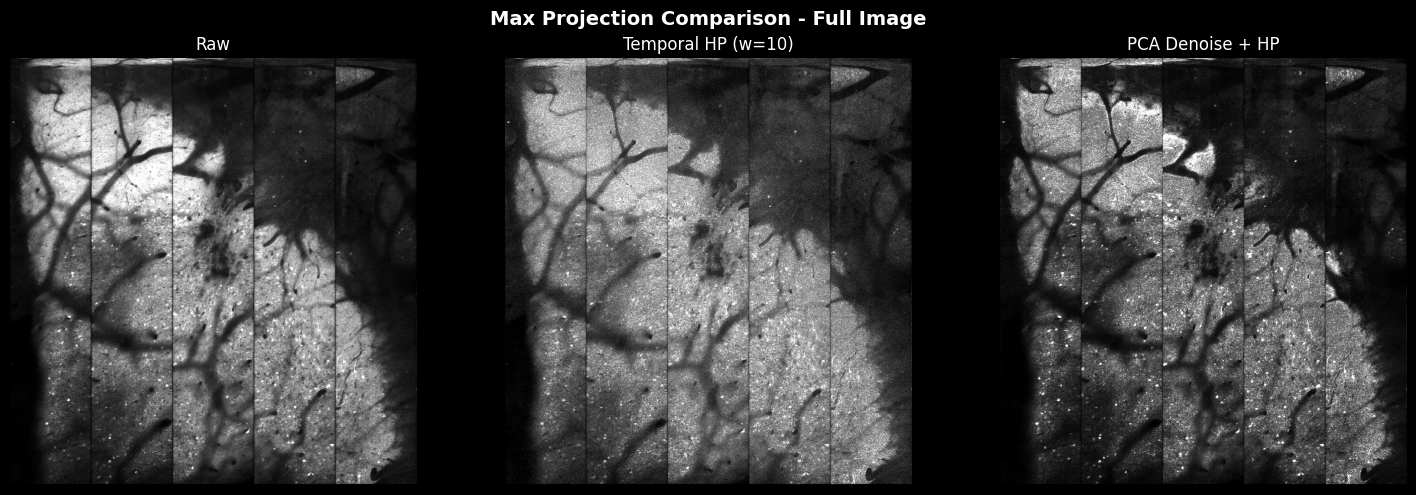

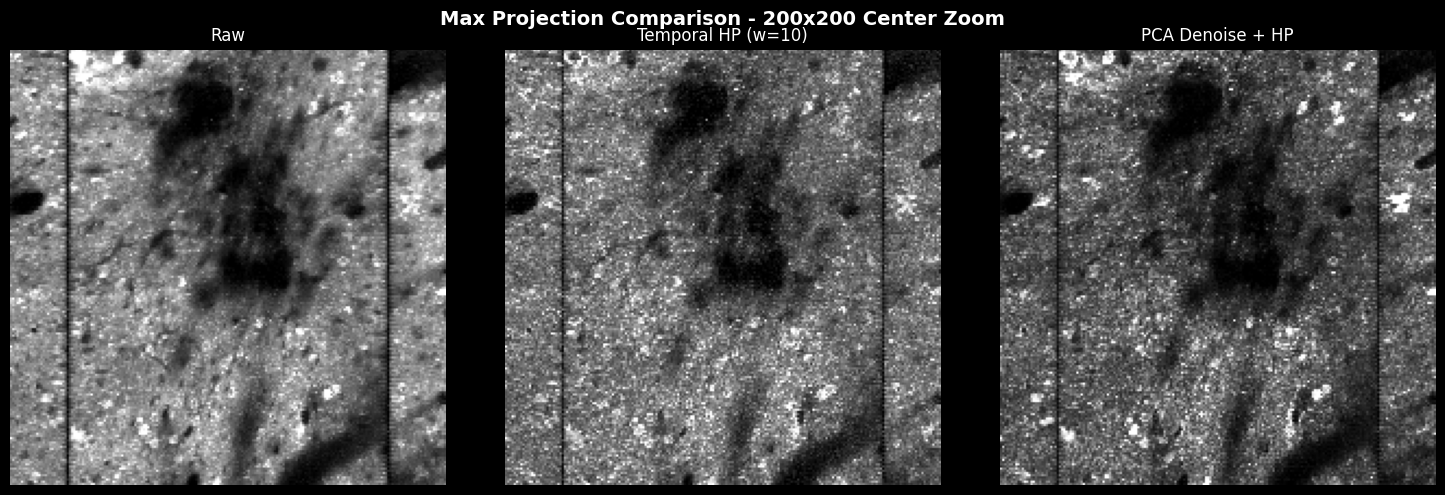

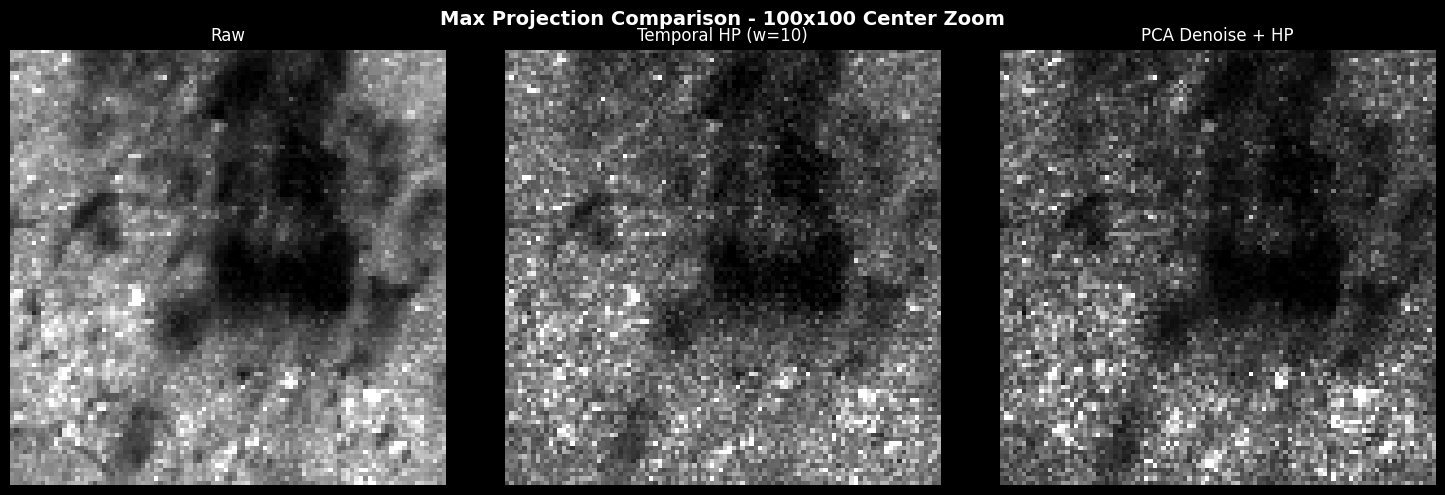

In [32]:
# Plot comparison of max projections
def normalize99(img):
    p1, p99 = np.percentile(img, [1, 99])
    return np.clip((img - p1) / (p99 - p1 + 1e-8), 0, 1)

Ly, Lx = max_proj_raw.shape
cy, cx = Ly // 2, Lx // 2

projections = {
    "Raw": max_proj_raw,
    f"Temporal HP (w={HIGH_PASS})": max_proj_hp,
    f"PCA Denoise + HP": max_proj_denoised,
}

# Full image comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, proj) in zip(axes, projections.items()):
    ax.imshow(normalize99(proj), cmap='gray')
    ax.set_title(name)
    ax.axis('off')
plt.suptitle("Max Projection Comparison - Full Image", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Zoomed comparison (200x200 center)
zs = 200
y1, y2 = cy - zs//2, cy + zs//2
x1, x2 = cx - zs//2, cx + zs//2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, proj) in zip(axes, projections.items()):
    ax.imshow(normalize99(proj[y1:y2, x1:x2]), cmap='gray')
    ax.set_title(name)
    ax.axis('off')
plt.suptitle(f"Max Projection Comparison - {zs}x{zs} Center Zoom", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Zoomed comparison (100x100 center)
zs = 100
y1, y2 = cy - zs//2, cy + zs//2
x1, x2 = cx - zs//2, cx + zs//2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, proj) in zip(axes, projections.items()):
    ax.imshow(normalize99(proj[y1:y2, x1:x2]), cmap='gray')
    ax.set_title(name)
    ax.axis('off')
plt.suptitle(f"Max Projection Comparison - {zs}x{zs} Center Zoom", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
# Run Cellpose on each preprocessing variant
from cellpose import models, core

model = models.CellposeModel(gpu=core.use_gpu())
DIAMETER = 6
CELLPROB_THRESHOLD = -6.0

cellpose_results = {}

for name, proj in projections.items():
    img = normalize99(proj)
    masks, _, _ = model.eval(
        img,
        diameter=DIAMETER,
        cellprob_threshold=CELLPROB_THRESHOLD,
        flow_threshold=0.0,
    )
    n_cells = masks.max()
    cellpose_results[name] = {'masks': masks, 'n_cells': n_cells, 'proj': proj}
    print(f"{name}: {n_cells} cells")

print(f"\nCell count summary:")
for name, r in cellpose_results.items():
    print(f"  {name}: {r['n_cells']} cells")

Resizing is deprecated in v4.0.1+


Raw: 745 cells


Resizing is deprecated in v4.0.1+


Temporal HP (w=10): 347 cells


Resizing is deprecated in v4.0.1+


PCA Denoise + HP: 616 cells

Cell count summary:
  Raw: 745 cells
  Temporal HP (w=10): 347 cells
  PCA Denoise + HP: 616 cells


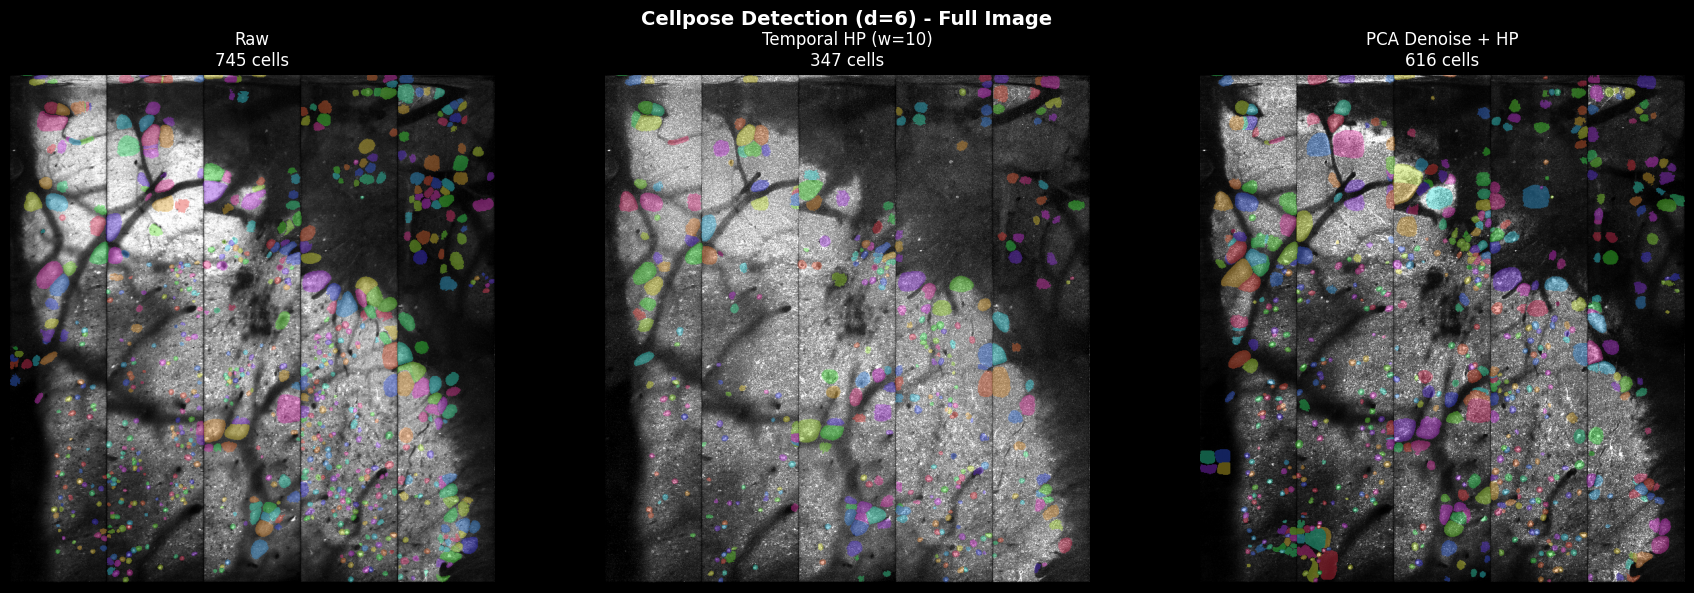

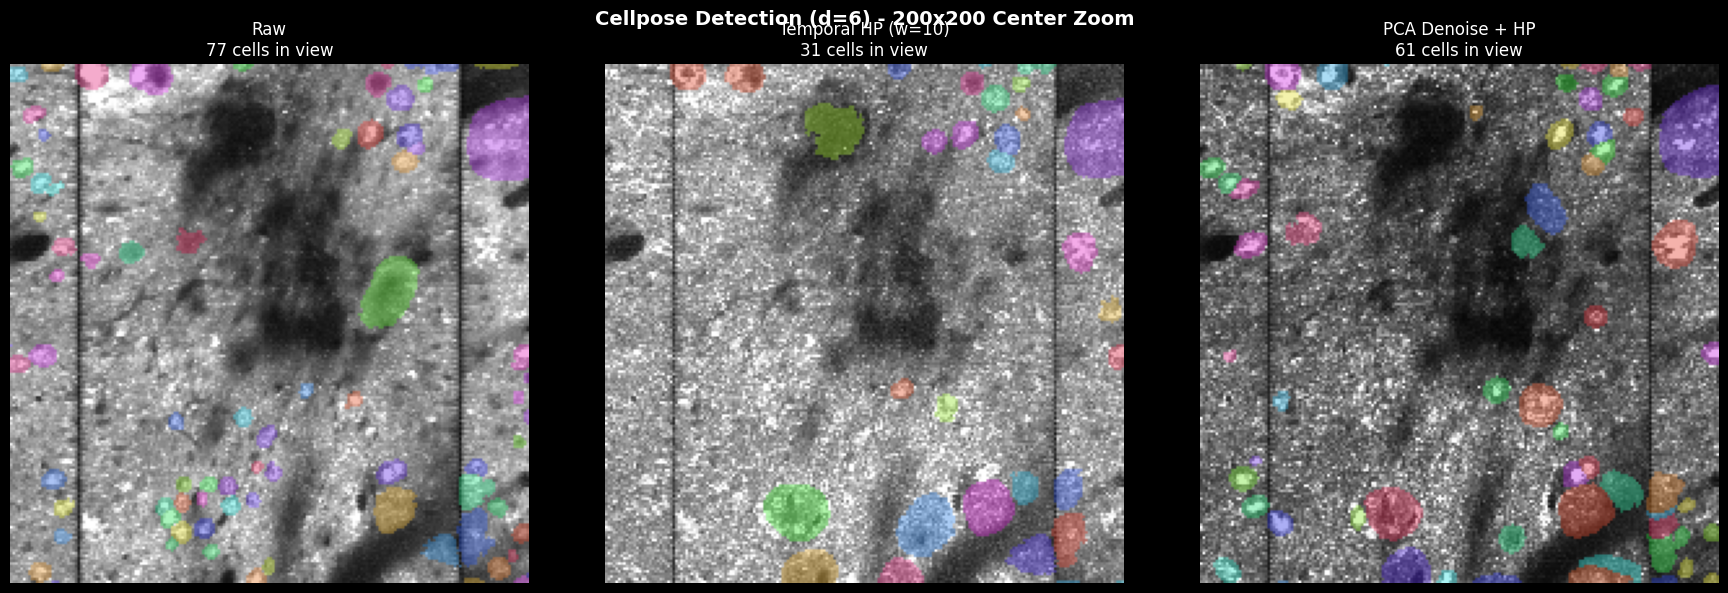

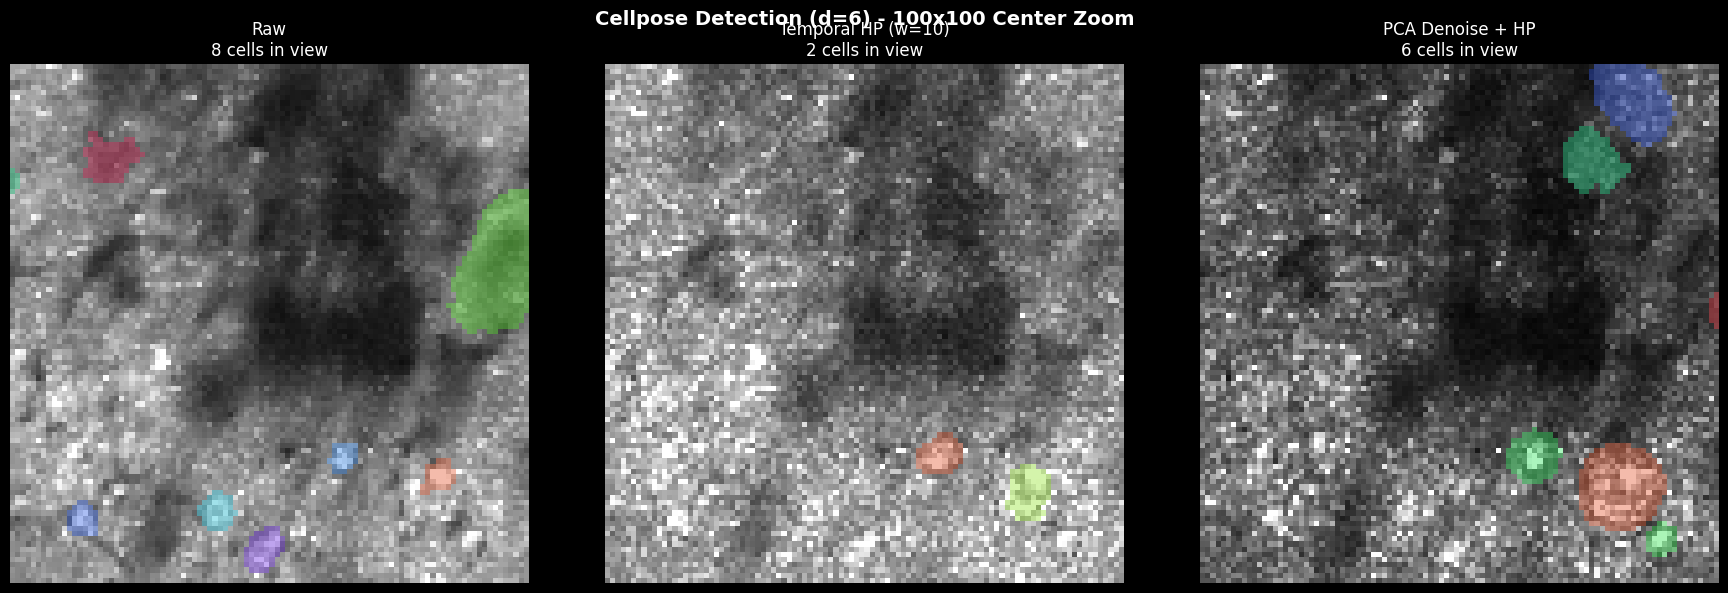

In [34]:
# Visualize Cellpose results with mask overlays
def mask_overlay(img, masks, alpha=0.4):
    from matplotlib.colors import hsv_to_rgb
    img_norm = normalize99(img)
    rgb = np.stack([img_norm]*3, axis=-1)
    if masks.max() > 0:
        n = masks.max()
        np.random.seed(42)
        colors = np.zeros((n+1, 3))
        for i in range(1, n+1):
            colors[i] = hsv_to_rgb([np.random.rand(), 0.8, 0.9])
        mask_rgb = colors[masks]
        mask_area = masks > 0
        rgb[mask_area] = (1-alpha)*rgb[mask_area] + alpha*mask_rgb[mask_area]
    return np.clip(rgb, 0, 1)

# Full image with masks
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, r) in zip(axes, cellpose_results.items()):
    overlay = mask_overlay(r['proj'], r['masks'])
    ax.imshow(overlay)
    ax.set_title(f"{name}\n{r['n_cells']} cells")
    ax.axis('off')
plt.suptitle(f"Cellpose Detection (d={DIAMETER}) - Full Image", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 200x200 zoom with masks
zs = 200
y1, y2 = cy - zs//2, cy + zs//2
x1, x2 = cx - zs//2, cx + zs//2

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, r) in zip(axes, cellpose_results.items()):
    overlay = mask_overlay(r['proj'], r['masks'])
    zoom_masks = r['masks'][y1:y2, x1:x2]
    n_zoom = len(np.unique(zoom_masks)) - 1
    ax.imshow(overlay[y1:y2, x1:x2])
    ax.set_title(f"{name}\n{n_zoom} cells in view")
    ax.axis('off')
plt.suptitle(f"Cellpose Detection (d={DIAMETER}) - {zs}x{zs} Center Zoom", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 100x100 zoom with masks
zs = 100
y1, y2 = cy - zs//2, cy + zs//2
x1, x2 = cx - zs//2, cx + zs//2

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, r) in zip(axes, cellpose_results.items()):
    overlay = mask_overlay(r['proj'], r['masks'])
    zoom_masks = r['masks'][y1:y2, x1:x2]
    n_zoom = len(np.unique(zoom_masks)) - 1
    ax.imshow(overlay[y1:y2, x1:x2])
    ax.set_title(f"{name}\n{n_zoom} cells in view")
    ax.axis('off')
plt.suptitle(f"Cellpose Detection (d={DIAMETER}) - {zs}x{zs} Center Zoom", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
OUTPUT_DIR = Path(r"D:/cj/2025-11-21/registration-segmentation")

ops_paths = lsp.pipeline(
    input_data=RAW_PATH,
    save_path=OUTPUT_DIR,
    planes=None,
    force_reg=False,
    force_detect=True,
    ops={
        "roidetect": 1,
        "anatomical_only":4,
        "high_pass":10,
        "diameter": 4,
        "denoise": 1,
        "spatial_hp_cp": 0.01,
    },
    reader_kwargs={"fix_phase": True, "use_fft": True,},
)

print(f"Results: {ops_paths}")

Loading input data...
  Input: D:\cj\2025-11-21\raw\vdaq1


Counting frames:   0%|          | 0/1 [00:00<?, ?it/s]

  Loaded as: MboRawArray

Dataset info:
  Shape: (970, 2, 772, 735)
  Frames: 970
  Planes: 2
  Dimensions: 772 x 735
  Phase correction: True
  FFT subpixel: True
  Frame rate: 5.40 Hz
  ROIs: 5
Importing suite2p packages...

Processing plan:
  Planes: [1, 2]
  Output: D:\cj\2025-11-21\registration-segmentation

Processing plane 1/2
  Writing binary (970 frames, 772x735)...


Saving data_raw.bin:   0%|          | 0/105 [00:00<?, ?it/s]

  Running Suite2p pipeline...
NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- REGISTRATION
Reference frame, 14.75 sec.
Registered 500/970 in 17.79s
Registered 970/970 in 35.53s
----------- Total 50.68 sec
----------- ROI DETECTION
Binning movie in chunks of length 07
Binned movie of size [138,772,735] created in 1.06 sec.


...

  Running Suite2p pipeline...
NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- REGISTRATION
Reference frame, 14.58 sec.
Registered 500/970 in 18.08s
Registered 970/970 in 35.45s
----------- Total 50.39 sec
----------- ROI DETECTION
Binning movie in chunks of length 07
Binned movie of size [138,772,735] created in 1.00 sec.


model_type argument is not used in v4.0.1+. Ignoring this argument...


Binned movie denoised (for cell detection only) in 6.23 sec.
>>>> CELLPOSE finding masks in max_proj
!NOTE! diameter set to 4.00 for cell detection with cellpose


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
no seeds found in get_masks_torch - no masks found.
Resizing is deprecated in v4.0.1+


>>>> 0 masks detected, median diameter = nan 
Detected 0 ROIs, 30.80 sec
----------- Total 38.23 sec.
no ROIs found, only ops.npy file saved
  Computing dF/F...
  Generating plots...
Plotting results for 452 accepted / 115 rejected ROIs
  Completed plane02_stitched in 133.5s

Generating volumetric statistics...

Pipeline complete!
  Processed: 2 planes
  Time: 267.6s
  Output: D:\cj\2025-11-21\registration-segmentation
Results: [WindowsPath('D:/cj/2025-11-21/registration-segmentation/plane01_stitched/ops.npy'), WindowsPath('D:/cj/2025-11-21/registration-segmentation/plane02_stitched/ops.npy')]


In [ ]:
# Load ops from registration
ops_path = ops_paths[0]
ops = np.load(ops_path, allow_pickle=True).item()
max_proj = ops["max_proj"].astype(np.float32)
Ly, Lx = ops["Ly"], ops["Lx"]

print(f"Loaded max_proj: {Ly}x{Lx}")
def normalize99(img):
    p1, p99 = np.percentile(img, [1, 99])
    return np.clip((img - p1) / (p99 - p1 + 1e-8), 0, 1)

# Best params from debug_lsp_pipeline: d=2, spa=0
DIAMETER = 4
CELLPROB_THRESHOLD = -6.0

model = models.CellposeModel(gpu=core.use_gpu())
img = normalize99(max_proj)

masks, flows, styles = model.eval(
    img,
    diameter=DIAMETER,
    cellprob_threshold=CELLPROB_THRESHOLD,
    flow_threshold=0.0,
)

n_cells = masks.max()
print(f"Detected {n_cells} cells")

Resizing is deprecated in v4.0.1+


Detected 758 cells


## Visualize

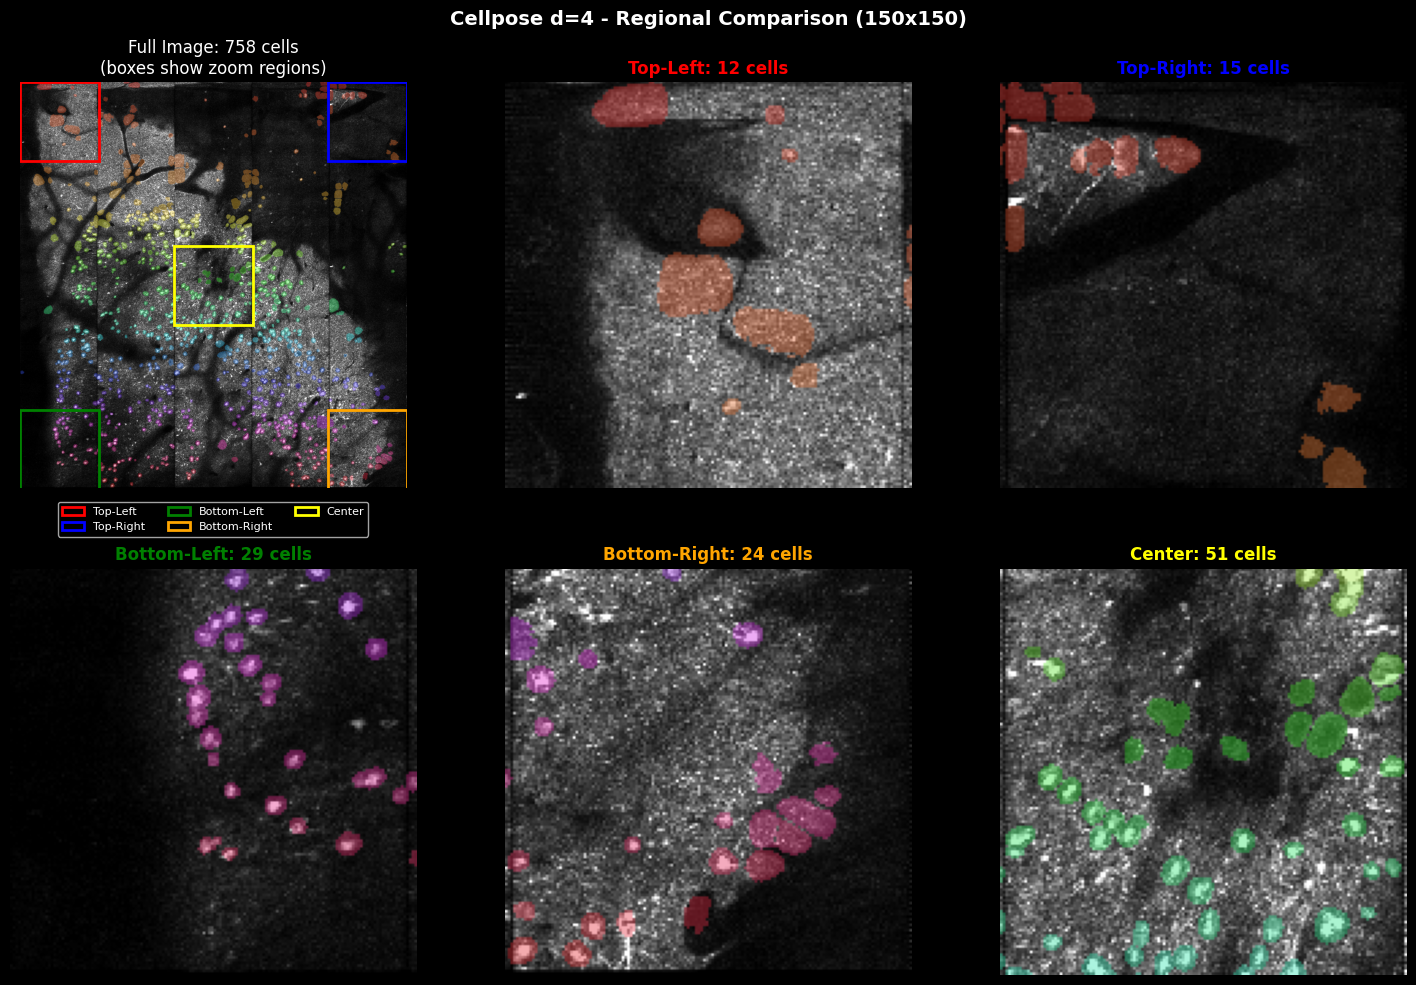

In [14]:
# Corner and edge zoom views
zs = 150  # zoom size for corners

# Define corner and edge regions
regions = {
    "Top-Left": (0, zs, 0, zs),
    "Top-Right": (0, zs, Lx-zs, Lx),
    "Bottom-Left": (Ly-zs, Ly, 0, zs),
    "Bottom-Right": (Ly-zs, Ly, Lx-zs, Lx),
    "Center": (cy-zs//2, cy+zs//2, cx-zs//2, cx+zs//2),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Full image with boxes showing regions
ax = axes[0]
ax.imshow(overlay)
colors_box = ['red', 'blue', 'green', 'orange', 'yellow']
for (name, (y1, y2, x1, x2)), c in zip(regions.items(), colors_box):
    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor=c, linewidth=2, label=name)
    ax.add_patch(rect)
ax.set_title(f"Full Image: {n_cells} cells\n(boxes show zoom regions)")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=3, fontsize=8)
ax.axis('off')

# Zoomed views
for ax, ((name, (y1, y2, x1, x2)), c) in zip(axes[1:], zip(regions.items(), colors_box)):
    zoom_masks = masks[y1:y2, x1:x2]
    n_zoom = len(np.unique(zoom_masks)) - 1
    ax.imshow(overlay[y1:y2, x1:x2])
    ax.set_title(f"{name}: {n_zoom} cells", color=c, fontweight='bold')
    ax.axis('off')

plt.suptitle(f"Cellpose d={DIAMETER} - Regional Comparison ({zs}x{zs})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()